<a href="https://colab.research.google.com/github/akubiszyn/Lies_detector/blob/main/CNN_facial_expression_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from google.colab import files
import torch
import torch.nn as nn
import torch.nn.init as init
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch.utils.data as data
from torch import optim
import torch.nn.functional as F
import os
import csv

# Torchvision
import torchvision
from torchvision import transforms
from torchvision import datasets

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

zip_path = '/content/drive/My Drive/ssne/archive.zip'
path = 'archive'

Mounted at /content/drive


In [ ]:
import os
import zipfile

if not os.path.exists(path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('.')

In [ ]:
transform_1 = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=1),
        transforms.RandomHorizontalFlip(0.5),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=0.5, std=[0.5])
    ]
)
transform_2 = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=1),
        transforms.RandomHorizontalFlip(0.5),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.RandomErasing(0.05),
        transforms.Normalize(mean=0.5, std=[0.5])
    ]
)
transform_3 = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=1),
        transforms.RandomHorizontalFlip(0.5),
        transforms.RandomRotation(20),
        transforms.ToTensor(),
        transforms.RandomErasing(0.1),
        transforms.Normalize(mean=0.5, std=[0.5])
    ]
)
transform_test = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor(),
        transforms.Normalize(mean=0.5, std=[0.5])
    ]
)

train_dataset_1 = datasets.ImageFolder(
    root="train",
    transform=transform_1
)
train_dataset_2 = datasets.ImageFolder(
    root="train",
    transform=transform_2
)
train_dataset_3 = datasets.ImageFolder(
    root="train",
    transform=transform_3
)
train_sample_count = len(train_dataset_1)
test_dataset = datasets.ImageFolder(
    root="test",
    transform=transform_test
)

batch = 128

train_loader_1 = data.DataLoader(train_dataset_1, batch_size=batch, shuffle=True)
train_loader_2 = data.DataLoader(train_dataset_2, batch_size=batch, shuffle=True)
train_loader_3 = data.DataLoader(train_dataset_3, batch_size=batch, shuffle=True)
test_loader = data.DataLoader(test_dataset, batch_size=batch, shuffle=True)

In [ ]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device:", device)

Device: cuda


In [ ]:
def display_frames(samples, num_rows, num_cols):
  [images, labels] = next(iter(samples))
  print(images[0].shape)
  fig, axes = plt.subplots(num_rows,num_cols)
  for i in range(16):
      image = images[i]
      image = image.permute(1, 2, 0)
      ax = axes[i // num_cols, i % num_cols]
      ax.imshow(image.squeeze(), cmap='gray')
      ax.set_title(f'Label: {labels[i]}')
      ax.axis('off')

  # plt.show()

torch.Size([1, 48, 48])


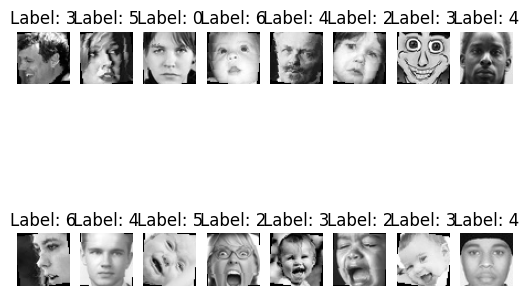

In [ ]:
display_frames(train_loader_1, 2, 8)

**Wzór na rozmiar wyjściowy warstwy konwolucyjnej (dla jednego wymiaru):**

$$
\text{Output} = \left\lfloor \frac{\text{Input} + 2 \cdot \text{Padding} - \text{Kernel Size}}{\text{Stride}} \right\rfloor + 1
$$

Gdzie:  
- **Input** – rozmiar wejściowy (np. szerokość/wysokość obrazu)  
- **Kernel Size** – rozmiar filtra  
- **Padding** – liczba pikseli dodanych z każdej strony  
- **Stride** – krok przesuwania filtra  
- ⌊⌋ – oznacza zaokrąglenie w dół


# CNN - 12 warstw

In [ ]:
class CNN12(nn.Module):
    def __init__(self, dropout):
        super().__init__()
        c_hid = 3
        act_fn = nn.LeakyReLU(0.01)
        self.conv_1 = nn.Conv2d(1, 1, kernel_size=7, padding=2) #48x48 => 46x46
        self.conv_2 = nn.Conv2d(1, 1, kernel_size=7, padding=1) #46x46 => 42x42
        self.conv_3 = nn.Conv2d(1, c_hid, kernel_size=5, padding=1) #42x42 => 40x40
        self.conv_4 = nn.Conv2d(c_hid, c_hid, kernel_size=5, padding=1) #40x40 => 38x38
        self.conv_5 = nn.Conv2d(c_hid, 4*c_hid, kernel_size=3, padding=1) #19x19 => 19x19
        self.conv_6 = nn.Conv2d(4*c_hid, 4*c_hid, kernel_size=3, padding=1) #19x19 => 19x19
        self.conv_7 = nn.Conv2d(4*c_hid, 8*c_hid, kernel_size=3, padding=1) #9x9 => 9x9
        self.conv_8 = nn.Conv2d(8*c_hid, 8*c_hid, kernel_size=3, padding=1) #9x9 => 9x9

        self.conv_9 = nn.Conv2d(8*c_hid, 16*c_hid, kernel_size=3, padding=1) #9x9 => 9x9
        self.conv_10 = nn.Conv2d(16*c_hid, 16*c_hid, kernel_size=3, padding=1) #9x9 => 9x9
        self.conv_11 = nn.Conv2d(16*c_hid, 32*c_hid, kernel_size=3, padding=1) #4x4 => 4x4
        self.conv_12 = nn.Conv2d(32*c_hid, 32*c_hid, kernel_size=3, padding=1) #4x4 => 4x4

        self.linear_1 = nn.Linear(1536, 972)
        self.linear_2 = nn.Linear(972, 486)
        self.linear_3 = nn.Linear(486, 243)
        self.linear_4 = nn.Linear(243, 7)

        # self.first_skip_conv = nn.Conv2d(1, c_hid, kernel_size=5)
        # self.second_skip_conv = nn.Conv2d(4*c_hid, 8*c_hid, kernel_size=3, stride=2)

        self.net_conv_1_2= nn.Sequential(

            self.conv_1,
            nn.BatchNorm2d(1),
            nn.Dropout(dropout),
            act_fn,
            self.conv_2,
            nn.BatchNorm2d(1),
            nn.Dropout(dropout),
            act_fn,

        )
        self.net_conv_3_4 = nn.Sequential(

            self.conv_3,
            nn.BatchNorm2d(c_hid),
            nn.Dropout(dropout),
            act_fn,
            self.conv_4,
            nn.BatchNorm2d(c_hid),
            nn.Dropout(dropout),
            act_fn
        )
        self.net_conv_5_6 = nn.Sequential(

            nn.MaxPool2d(kernel_size=2, stride=2),

            self.conv_5,
            nn.BatchNorm2d(4*c_hid),
            nn.Dropout(dropout),
            act_fn,
            self.conv_6,
            nn.BatchNorm2d(4*c_hid),
            nn.Dropout(dropout),
            act_fn,
        )

        self.net_conv_7_8 = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),

            self.conv_7,
            nn.BatchNorm2d(8*c_hid),
            nn.Dropout(dropout),
            act_fn,
            self.conv_8,
            nn.BatchNorm2d(8*c_hid),
            nn.Dropout(dropout),
            act_fn
        )
        self.net_conv_9_10 = nn.Sequential(

            self.conv_9,
            nn.BatchNorm2d(16*c_hid),
            nn.Dropout(dropout),
            act_fn,
            self.conv_10,
            nn.BatchNorm2d(16*c_hid),
            nn.Dropout(dropout),
            act_fn
        )

        self.net_conv_11_12 = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),

            self.conv_11,
            nn.BatchNorm2d(32*c_hid),
            nn.Dropout(dropout),
            act_fn,
            self.conv_12,
            nn.BatchNorm2d(32*c_hid),
            nn.Dropout(dropout),
            act_fn
        )
        self.linear_net = nn.Sequential(

            nn.Flatten(),

            self.linear_1,
            nn.BatchNorm1d(972),
            act_fn,
            nn.Dropout(dropout),

            self.linear_2,
            nn.BatchNorm1d(486),
            act_fn,
            nn.Dropout(dropout),

            self.linear_3,
            nn.BatchNorm1d(243),
            act_fn,
            nn.Dropout(dropout),

            self.linear_4,
            nn.Softmax(dim=1)
        )

        # Inicjalizacja wag
        for layer in [self.conv_1, self.conv_2, self.conv_3, self.conv_4, self.conv_5, self.conv_6, self.conv_7, self.conv_8, self.conv_9, self.conv_10, self.conv_11, self.conv_12]:
            init.xavier_normal_(layer.weight)

        for layer in [self.linear_1, self.linear_2, self.linear_3, self.linear_4]:
            init.xavier_normal_(layer.weight)

    def conv_layers(self, x):
        features_after_2 = self.net_conv_1_2(x)
        # first_skip_connection = self.first_skip_conv(features_after_2)
        features_after_4 = self.net_conv_3_4(features_after_2) #+ first_skip_connection
        features_after_6 = self.net_conv_5_6(features_after_4)
        # second_skip_connection = self.second_skip_conv(features_after_6)
        features_after_8 = self.net_conv_7_8(features_after_6) #+ second_skip_connection
        features_after_10 = self.net_conv_9_10(features_after_8)
        features_after_all_convs = self.net_conv_11_12(features_after_10)
        return features_after_all_convs


    def forward(self, x):
        return self.linear_net(self.conv_layers(x))

    def extract_features(self, x):
        features = self.conv_layers(x)
        return features.view(features.size(0), -1)

# CNN - 8 warstw

In [ ]:
# bez połączeń pomijających

class CNN8(nn.Module):
    def __init__(self, dropout):
        super().__init__()
        c_hid = 3
        act_fn = nn.LeakyReLU(0.01)
        self.conv_1 = nn.Conv2d(1, 1, kernel_size=7, padding=2) #48x48 => 46x46
        self.conv_2 = nn.Conv2d(1, 1, kernel_size=7, padding=1) #46x46 => 42x42
        self.conv_3 = nn.Conv2d(1, c_hid, kernel_size=5, padding=1) #42x42 => 40x40
        self.conv_4 = nn.Conv2d(c_hid, c_hid, kernel_size=5, padding=1) #40x40 => 38x38
        self.conv_5 = nn.Conv2d(c_hid, 4*c_hid, kernel_size=3, padding=1) #19x19 => 19x19
        self.conv_6 = nn.Conv2d(4*c_hid, 4*c_hid, kernel_size=3, padding=1) #19x19 => 19x19
        self.conv_7 = nn.Conv2d(4*c_hid, 8*c_hid, kernel_size=3, padding=1) #9x9 => 9x9
        self.conv_8 = nn.Conv2d(8*c_hid, 8*c_hid, kernel_size=3, padding=1) #9x9 => 9x9

        self.linear_1 = nn.Linear(1944, 972)
        self.linear_2 = nn.Linear(972, 486)
        self.linear_3 = nn.Linear(486, 243)
        self.linear_4 = nn.Linear(243, 7)

        # self.first_skip_conv = nn.Conv2d(1, c_hid, kernel_size=5)
        # self.second_skip_conv = nn.Conv2d(4*c_hid, 8*c_hid, kernel_size=3, stride=2)

        self.net_conv_1_2= nn.Sequential(

            self.conv_1,
            nn.BatchNorm2d(1),
            nn.Dropout(dropout),
            act_fn,
            self.conv_2,
            nn.BatchNorm2d(1),
            nn.Dropout(dropout),
            act_fn,

        )
        self.net_conv_3_4 = nn.Sequential(

            self.conv_3,
            nn.BatchNorm2d(c_hid),
            nn.Dropout(dropout),
            act_fn,
            self.conv_4,
            nn.BatchNorm2d(c_hid),
            nn.Dropout(dropout),
            act_fn
        )
        self.net_conv_5_6 = nn.Sequential(

            nn.MaxPool2d(kernel_size=2, stride=2),

            self.conv_5,
            nn.BatchNorm2d(4*c_hid),
            nn.Dropout(dropout),
            act_fn,
            self.conv_6,
            nn.BatchNorm2d(4*c_hid),
            nn.Dropout(dropout),
            act_fn,
        )

        self.net_conv_7_8 = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),

            self.conv_7,
            nn.BatchNorm2d(8*c_hid),
            nn.Dropout(dropout),
            act_fn,
            self.conv_8,
            nn.BatchNorm2d(8*c_hid),
            nn.Dropout(dropout),
            act_fn
        )
        self.linear_net = nn.Sequential(

            nn.Flatten(),

            self.linear_1,
            nn.BatchNorm1d(972),
            act_fn,
            nn.Dropout(dropout),

            self.linear_2,
            nn.BatchNorm1d(486),
            act_fn,
            nn.Dropout(dropout),

            self.linear_3,
            nn.BatchNorm1d(243),
            act_fn,
            nn.Dropout(dropout),

            self.linear_4,
            nn.Softmax(dim=1)
        )

        # Inicjalizacja wag
        for layer in [self.conv_1, self.conv_2, self.conv_3, self.conv_4, self.conv_5, self.conv_6, self.conv_7, self.conv_8]:
            init.xavier_normal_(layer.weight)

        for layer in [self.linear_1, self.linear_2, self.linear_3, self.linear_4]:
            init.xavier_normal_(layer.weight)

    def conv_layers(self, x):
        features_after_2 = self.net_conv_1_2(x)
        # first_skip_connection = self.first_skip_conv(features_after_2)
        features_after_4 = self.net_conv_3_4(features_after_2) #+ first_skip_connection
        features_after_6 = self.net_conv_5_6(features_after_4)
        # second_skip_connection = self.second_skip_conv(features_after_6)
        features_after_all_convs = self.net_conv_7_8(features_after_6) #+ second_skip_connection
        return features_after_all_convs


    def forward(self, x):
        return self.linear_net(self.conv_layers(x))

    def extract_features(self, x):
        features = self.conv_layers(x)
        return features.view(features.size(0), -1)


In [ ]:
# bez połączeń pomijających

class CNN_1(nn.Module):
    def __init__(self, dropout):
        super().__init__()
        c_hid = 3
        act_fn = nn.LeakyReLU(0.01)
        self.conv_1 = nn.Conv2d(1, 1, kernel_size=7, padding=2) #48x48 => 46x46
        self.conv_2 = nn.Conv2d(1, 1, kernel_size=7, padding=1) #46x46 => 42x42
        self.conv_3 = nn.Conv2d(1, c_hid, kernel_size=5, padding=1) #42x42 => 40x40
        self.conv_4 = nn.Conv2d(c_hid, c_hid, kernel_size=5, padding=1) #40x40 => 38x38
        self.conv_5 = nn.Conv2d(c_hid, 4*c_hid, kernel_size=3, padding=1) #19x19 => 19x19
        self.conv_6 = nn.Conv2d(4*c_hid, 4*c_hid, kernel_size=3, padding=1) #19x19 => 19x19
        self.conv_7 = nn.Conv2d(4*c_hid, 8*c_hid, kernel_size=3, padding=1) #9x9 => 9x9
        self.conv_8 = nn.Conv2d(8*c_hid, 8*c_hid, kernel_size=3, padding=1) #9x9 => 9x9

        self.linear_1 = nn.Linear(1944, 972)
        self.linear_2 = nn.Linear(972, 486)
        self.linear_3 = nn.Linear(486, 243)
        self.linear_4 = nn.Linear(243, 7)

        self.first_skip_conv = nn.Conv2d(1, c_hid, kernel_size=5)
        # self.second_skip_conv = nn.Conv2d(4*c_hid, 8*c_hid, kernel_size=3, stride=2)

        self.net_conv_1_2= nn.Sequential(

            self.conv_1,
            nn.BatchNorm2d(1),
            nn.Dropout(dropout),
            act_fn,
            self.conv_2,
            nn.BatchNorm2d(1),
            nn.Dropout(dropout),
            act_fn,

        )
        self.net_conv_3_4 = nn.Sequential(

            self.conv_3,
            nn.BatchNorm2d(c_hid),
            nn.Dropout(dropout),
            act_fn,
            self.conv_4,
            nn.BatchNorm2d(c_hid),
            nn.Dropout(dropout),
            act_fn
        )
        self.net_conv_5_6 = nn.Sequential(

            nn.MaxPool2d(kernel_size=2, stride=2),

            self.conv_5,
            nn.BatchNorm2d(4*c_hid),
            nn.Dropout(dropout),
            act_fn,
            self.conv_6,
            nn.BatchNorm2d(4*c_hid),
            nn.Dropout(dropout),
            act_fn,
        )

        self.net_conv_7_8 = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),

            self.conv_7,
            nn.BatchNorm2d(8*c_hid),
            nn.Dropout(dropout),
            act_fn,
            self.conv_8,
            nn.BatchNorm2d(8*c_hid),
            nn.Dropout(dropout),
            act_fn
        )
        self.linear_net = nn.Sequential(

            nn.Flatten(),

            self.linear_1,
            nn.BatchNorm1d(972),
            act_fn,
            nn.Dropout(dropout),

            self.linear_2,
            nn.BatchNorm1d(486),
            act_fn,
            nn.Dropout(dropout),

            self.linear_3,
            nn.BatchNorm1d(243),
            act_fn,
            nn.Dropout(dropout),

            self.linear_4,
            nn.Softmax(dim=1)
        )

        # Inicjalizacja wag
        for layer in [self.conv_1, self.conv_2, self.conv_3, self.conv_4, self.conv_5, self.conv_6, self.conv_7, self.conv_8]:
            init.xavier_normal_(layer.weight)

        for layer in [self.linear_1, self.linear_2, self.linear_3, self.linear_4]:
            init.xavier_normal_(layer.weight)

    def conv_layers(self, x):
        features_after_2 = self.net_conv_1_2(x)
        first_skip_connection = self.first_skip_conv(features_after_2)
        features_after_4 = self.net_conv_3_4(features_after_2) + first_skip_connection
        features_after_6 = self.net_conv_5_6(features_after_4)
        # second_skip_connection = self.second_skip_conv(features_after_6)
        features_after_all_convs = self.net_conv_7_8(features_after_6) #+ second_skip_connection
        return features_after_all_convs


    def forward(self, x):
        return self.linear_net(self.conv_layers(x))

    def extract_features(self, x):
        features = self.conv_layers(x)
        return features.view(features.size(0), -1)

In [ ]:
# z połączeniami pomijającymi

class CNN_2(nn.Module):
    def __init__(self, dropout):
        super().__init__()
        c_hid = 3
        act_fn = nn.LeakyReLU(0.01)
        self.conv_1 = nn.Conv2d(1, 1, kernel_size=7, padding=2) #48x48 => 46x46
        self.conv_2 = nn.Conv2d(1, 1, kernel_size=7, padding=1) #46x46 => 42x42
        self.conv_3 = nn.Conv2d(1, c_hid, kernel_size=5, padding=1) #42x42 => 40x40
        self.conv_4 = nn.Conv2d(c_hid, c_hid, kernel_size=5, padding=1) #40x40 => 38x38
        self.conv_5 = nn.Conv2d(c_hid, 4*c_hid, kernel_size=3, padding=1) #19x19 => 19x19
        self.conv_6 = nn.Conv2d(4*c_hid, 4*c_hid, kernel_size=3, padding=1) #19x19 => 19x19
        self.conv_7 = nn.Conv2d(4*c_hid, 8*c_hid, kernel_size=3, padding=1) #9x9 => 9x9
        self.conv_8 = nn.Conv2d(8*c_hid, 8*c_hid, kernel_size=3, padding=1) #9x9 => 9x9

        self.linear_1 = nn.Linear(1944, 972)
        self.linear_2 = nn.Linear(972, 486)
        self.linear_3 = nn.Linear(486, 243)
        self.linear_4 = nn.Linear(243, 7)

        self.first_skip_conv = nn.Conv2d(1, c_hid, kernel_size=5)
        self.second_skip_conv = nn.Conv2d(4*c_hid, 8*c_hid, kernel_size=3, stride=2)

        self.net_conv_1_2= nn.Sequential(

            self.conv_1,
            nn.BatchNorm2d(1),
            nn.Dropout(dropout),
            act_fn,
            self.conv_2,
            nn.BatchNorm2d(1),
            nn.Dropout(dropout),
            act_fn,

        )
        self.net_conv_3_4 = nn.Sequential(

            self.conv_3,
            nn.BatchNorm2d(c_hid),
            nn.Dropout(dropout),
            act_fn,
            self.conv_4,
            nn.BatchNorm2d(c_hid),
            nn.Dropout(dropout),
            act_fn
        )
        self.net_conv_5_6 = nn.Sequential(

            nn.MaxPool2d(kernel_size=2, stride=2),

            self.conv_5,
            nn.BatchNorm2d(4*c_hid),
            nn.Dropout(dropout),
            act_fn,
            self.conv_6,
            nn.BatchNorm2d(4*c_hid),
            nn.Dropout(dropout),
            act_fn,
        )

        self.net_conv_7_8 = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),

            self.conv_7,
            nn.BatchNorm2d(8*c_hid),
            nn.Dropout(dropout),
            act_fn,
            self.conv_8,
            nn.BatchNorm2d(8*c_hid),
            nn.Dropout(dropout),
            act_fn
        )
        self.linear_net = nn.Sequential(

            nn.Flatten(),

            self.linear_1,
            nn.BatchNorm1d(972),
            act_fn,
            nn.Dropout(dropout),

            self.linear_2,
            nn.BatchNorm1d(486),
            act_fn,
            nn.Dropout(dropout),

            self.linear_3,
            nn.BatchNorm1d(243),
            act_fn,
            nn.Dropout(dropout),

            self.linear_4
        )

        # Inicjalizacja wag
        for layer in [self.conv_1, self.conv_2, self.conv_3, self.conv_4, self.conv_5, self.conv_6, self.conv_7, self.conv_8]:
            init.xavier_normal_(layer.weight)

        for layer in [self.linear_1, self.linear_2, self.linear_3, self.linear_4]:
            init.xavier_normal_(layer.weight)

    def conv_layers(self, x):
        features_after_2 = self.net_conv_1_2(x)
        first_skip_connection = self.first_skip_conv(features_after_2)
        features_after_4 = self.net_conv_3_4(features_after_2) + first_skip_connection
        features_after_6 = self.net_conv_5_6(features_after_4)
        second_skip_connection = self.second_skip_conv(features_after_6)
        features_after_all_convs = self.net_conv_7_8(features_after_6) + second_skip_connection
        return features_after_all_convs


    def forward(self, x):
        return self.linear_net(self.conv_layers(x))

    def extract_features(self, x):
        features = self.conv_layers(x)
        return features.view(features.size(0), -1)

# CNN - 4 warstwy

In [ ]:
class CNN4(nn.Module):
    def __init__(self, dropout):
        super().__init__()
        c_hid = 3
        act_fn = nn.LeakyReLU(0.01)
        self.conv_1 = nn.Conv2d(1, c_hid, kernel_size=7, padding=1) #48x48 => 44x44
        self.conv_2 = nn.Conv2d(c_hid,4*c_hid, kernel_size=7, padding=1) #44x44 => 40x40
        self.conv_3 = nn.Conv2d(4*c_hid, 8*c_hid, kernel_size=7, padding=1) #20x20 => 16x16
        self.conv_4 = nn.Conv2d(8*c_hid, 8*c_hid, kernel_size=7, padding=1) #16x16 => 12x12

        self.linear_1 = nn.Linear(3456, 1728)
        self.linear_2 = nn.Linear(1728, 864)
        self.linear_3 = nn.Linear(864, 243)
        self.linear_4 = nn.Linear(243, 7)

        # self.first_skip_conv = nn.Conv2d(1, c_hid, kernel_size=5)
        # self.second_skip_conv = nn.Conv2d(4*c_hid, 8*c_hid, kernel_size=3, stride=2)

        self.net_conv_1_2= nn.Sequential(

            self.conv_1,
            nn.BatchNorm2d(c_hid),
            nn.Dropout(dropout),
            act_fn,
            self.conv_2,
            nn.BatchNorm2d(4*c_hid),
            nn.Dropout(dropout),
            act_fn,

        )
        self.net_conv_3_4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),

            self.conv_3,
            nn.BatchNorm2d(8*c_hid),
            nn.Dropout(dropout),
            act_fn,
            self.conv_4,
            nn.BatchNorm2d(8*c_hid),
            nn.Dropout(dropout),
            act_fn
        )

        self.linear_net = nn.Sequential(

            nn.Flatten(),

            self.linear_1,
            nn.BatchNorm1d(1728),
            act_fn,
            nn.Dropout(dropout),

            self.linear_2,
            nn.BatchNorm1d(864),
            act_fn,
            nn.Dropout(dropout),

            self.linear_3,
            nn.BatchNorm1d(243),
            act_fn,
            nn.Dropout(dropout),

            self.linear_4,
            nn.Softmax(dim=1)
        )

        # Inicjalizacja wag
        for layer in [self.conv_1, self.conv_2, self.conv_3, self.conv_4]:
            init.xavier_normal_(layer.weight)

        for layer in [self.linear_1, self.linear_2, self.linear_3, self.linear_4]:
            init.xavier_normal_(layer.weight)

    def conv_layers(self, x):
        features_after_2 = self.net_conv_1_2(x)
        # first_skip_connection = self.first_skip_conv(features_after_2)
        features_after_4 = self.net_conv_3_4(features_after_2) #+ first_skip_connection
        return features_after_4


    def forward(self, x):
        return self.linear_net(self.conv_layers(x))

    def extract_features(self, x):
        features = self.conv_layers(x)
        return features.view(features.size(0), -1)

In [ ]:
class CNN4_1(nn.Module):
    def __init__(self, dropout):
        super().__init__()
        c_hid = 3
        act_fn = nn.LeakyReLU(0.01)
        self.conv_1 = nn.Conv2d(1, c_hid, kernel_size=7, padding=1) #48x48 => 44x44
        self.conv_2 = nn.Conv2d(c_hid,4*c_hid, kernel_size=7, padding=1) #44x44 => 40x40
        self.conv_3 = nn.Conv2d(4*c_hid, 8*c_hid, kernel_size=7, padding=1) #20x20 => 16x16
        self.conv_4 = nn.Conv2d(8*c_hid, 8*c_hid, kernel_size=7, padding=1) #16x16 => 12x12

        self.linear_1 = nn.Linear(3456, 1728)
        self.linear_2 = nn.Linear(1728, 864)
        self.linear_3 = nn.Linear(864, 243)
        self.linear_4 = nn.Linear(243, 7)

        self.first_skip_conv = nn.Conv2d(4*c_hid, 8*c_hid, kernel_size=17, stride=2)
        # self.second_skip_conv = nn.Conv2d(4*c_hid, 8*c_hid, kernel_size=3, stride=2)

        self.net_conv_1_2= nn.Sequential(

            self.conv_1,
            nn.BatchNorm2d(c_hid),
            nn.Dropout(dropout),
            act_fn,
            self.conv_2,
            nn.BatchNorm2d(4*c_hid),
            nn.Dropout(dropout),
            act_fn,

        )
        self.net_conv_3_4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),

            self.conv_3,
            nn.BatchNorm2d(8*c_hid),
            nn.Dropout(dropout),
            act_fn,
            self.conv_4,
            nn.BatchNorm2d(8*c_hid),
            nn.Dropout(dropout),
            act_fn
        )

        self.linear_net = nn.Sequential(

            nn.Flatten(),

            self.linear_1,
            nn.BatchNorm1d(1728),
            act_fn,
            nn.Dropout(dropout),

            self.linear_2,
            nn.BatchNorm1d(864),
            act_fn,
            nn.Dropout(dropout),

            self.linear_3,
            nn.BatchNorm1d(243),
            act_fn,
            nn.Dropout(dropout),

            self.linear_4,
            nn.Softmax(dim=1)
        )

        # Inicjalizacja wag
        for layer in [self.conv_1, self.conv_2, self.conv_3, self.conv_4]:
            init.xavier_normal_(layer.weight)

        for layer in [self.linear_1, self.linear_2, self.linear_3, self.linear_4]:
            init.xavier_normal_(layer.weight)

    def conv_layers(self, x):
        features_after_2 = self.net_conv_1_2(x)
        first_skip_connection = self.first_skip_conv(features_after_2)
        features_after_4 = self.net_conv_3_4(features_after_2) + first_skip_connection
        return features_after_4


    def forward(self, x):
        return self.linear_net(self.conv_layers(x))

    def extract_features(self, x):
        features = self.conv_layers(x)
        return features.view(features.size(0), -1)

In [ ]:
class CNN4_deeper(nn.Module):
    def __init__(self, dropout):
        super().__init__()
        c_hid = 4
        act_fn = nn.LeakyReLU(0.01)
        self.conv_1 = nn.Conv2d(1, c_hid, kernel_size=7, padding=1) #48x48 => 44x44
        self.conv_2 = nn.Conv2d(c_hid,4*c_hid, kernel_size=7, padding=1) #44x44 => 40x40
        self.conv_3 = nn.Conv2d(4*c_hid, 8*c_hid, kernel_size=7, padding=1) #20x20 => 16x16
        self.conv_4 = nn.Conv2d(8*c_hid, 12*c_hid, kernel_size=7, padding=1) #16x16 => 12x12

        self.linear_1 = nn.Linear(6912, 2304)
        self.linear_2 = nn.Linear(2304, 1152)
        self.linear_3 = nn.Linear(1152, 512)
        self.linear_4 = nn.Linear(512, 7)

        self.first_skip_conv = nn.Conv2d(1, c_hid, kernel_size=5)

        self.net_conv_1_2= nn.Sequential(

            self.conv_1,
            nn.BatchNorm2d(c_hid),
            nn.Dropout(dropout),
            act_fn,
            self.conv_2,
            nn.BatchNorm2d(4*c_hid),
            nn.Dropout(dropout),
            act_fn,

        )
        self.net_conv_3_4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),

            self.conv_3,
            nn.BatchNorm2d(8*c_hid),
            nn.Dropout(dropout),
            act_fn,
            self.conv_4,
            nn.BatchNorm2d(12*c_hid),
            nn.Dropout(dropout),
            act_fn
        )

        self.linear_net = nn.Sequential(

            nn.Flatten(),

            self.linear_1,
            nn.BatchNorm1d(2304),
            act_fn,
            nn.Dropout(dropout),

            self.linear_2,
            nn.BatchNorm1d(1152),
            act_fn,
            nn.Dropout(dropout),

            self.linear_3,
            nn.BatchNorm1d(512),
            act_fn,
            nn.Dropout(dropout),

            self.linear_4,
            nn.Softmax(dim=1)
        )

        # Inicjalizacja wag
        for layer in [self.conv_1, self.conv_2, self.conv_3, self.conv_4]:
            init.xavier_normal_(layer.weight)

        for layer in [self.linear_1, self.linear_2, self.linear_3, self.linear_4]:
            init.xavier_normal_(layer.weight)

    def conv_layers(self, x):
        features_after_2 = self.net_conv_1_2(x)
        # first_skip_connection = self.first_skip_conv(features_after_2)
        features_after_4 = self.net_conv_3_4(features_after_2) #+ first_skip_connection
        return features_after_4


    def forward(self, x):
        return self.linear_net(self.conv_layers(x))

    def extract_features(self, x):
        features = self.conv_layers(x)
        return features.view(features.size(0), -1)

In [ ]:
class CNN4_deepest(nn.Module):
    def __init__(self, dropout):
        super().__init__()
        c_hid = 5
        act_fn = nn.LeakyReLU(0.01)
        self.conv_1 = nn.Conv2d(1, c_hid, kernel_size=7, padding=1) #48x48 => 44x44
        self.conv_2 = nn.Conv2d(c_hid,4*c_hid, kernel_size=7, padding=1) #44x44 => 40x40
        self.conv_3 = nn.Conv2d(4*c_hid, 8*c_hid, kernel_size=7, padding=1) #20x20 => 16x16
        self.conv_4 = nn.Conv2d(8*c_hid, 12*c_hid, kernel_size=7, padding=1) #16x16 => 12x12

        self.linear_1 = nn.Linear(8640, 4320)
        self.linear_2 = nn.Linear(4320, 1152)
        self.linear_3 = nn.Linear(1152, 512)
        self.linear_4 = nn.Linear(512, 7)

        self.first_skip_conv = nn.Conv2d(1, c_hid, kernel_size=5)

        self.net_conv_1_2= nn.Sequential(

            self.conv_1,
            nn.BatchNorm2d(c_hid),
            nn.Dropout(dropout),
            act_fn,
            self.conv_2,
            nn.BatchNorm2d(4*c_hid),
            nn.Dropout(dropout),
            act_fn,

        )
        self.net_conv_3_4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),

            self.conv_3,
            nn.BatchNorm2d(8*c_hid),
            nn.Dropout(dropout),
            act_fn,
            self.conv_4,
            nn.BatchNorm2d(12*c_hid),
            nn.Dropout(dropout),
            act_fn
        )

        self.linear_net = nn.Sequential(

            nn.Flatten(),

            self.linear_1,
            nn.BatchNorm1d(4320),
            act_fn,
            nn.Dropout(dropout),

            self.linear_2,
            nn.BatchNorm1d(1152),
            act_fn,
            nn.Dropout(dropout),

            self.linear_3,
            nn.BatchNorm1d(512),
            act_fn,
            nn.Dropout(dropout),

            self.linear_4,
            nn.Softmax(dim=1)
        )

        # Inicjalizacja wag
        for layer in [self.conv_1, self.conv_2, self.conv_3, self.conv_4]:
            init.xavier_normal_(layer.weight)

        for layer in [self.linear_1, self.linear_2, self.linear_3, self.linear_4]:
            init.xavier_normal_(layer.weight)

    def conv_layers(self, x):
        features_after_2 = self.net_conv_1_2(x)
        # first_skip_connection = self.first_skip_conv(features_after_2)
        features_after_4 = self.net_conv_3_4(features_after_2) #+ first_skip_connection
        return features_after_4


    def forward(self, x):
        return self.linear_net(self.conv_layers(x))

    def extract_features(self, x):
        features = self.conv_layers(x)
        return features.view(features.size(0), -1)

In [ ]:
class CNN4_deepest_2(nn.Module):
    def __init__(self, dropout):
        super().__init__()
        c_hid = 8
        act_fn = nn.LeakyReLU(0.01)
        self.conv_1 = nn.Conv2d(1, c_hid, kernel_size=7, padding=1) #48x48 => 44x44
        self.conv_2 = nn.Conv2d(c_hid,4*c_hid, kernel_size=7, padding=1) #44x44 => 40x40
        self.conv_3 = nn.Conv2d(4*c_hid, 8*c_hid, kernel_size=7, padding=1) #20x20 => 16x16
        self.conv_4 = nn.Conv2d(8*c_hid, 12*c_hid, kernel_size=7, padding=1) #16x16 => 12x12

        self.linear_1 = nn.Linear(13824, 4320)
        self.linear_2 = nn.Linear(4320, 1152)
        self.linear_3 = nn.Linear(1152, 512)
        self.linear_4 = nn.Linear(512, 7)

        self.first_skip_conv = nn.Conv2d(1, c_hid, kernel_size=5)

        self.net_conv_1_2= nn.Sequential(

            self.conv_1,
            nn.BatchNorm2d(c_hid),
            nn.Dropout(dropout),
            act_fn,
            self.conv_2,
            nn.BatchNorm2d(4*c_hid),
            nn.Dropout(dropout),
            act_fn,

        )
        self.net_conv_3_4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),

            self.conv_3,
            nn.BatchNorm2d(8*c_hid),
            nn.Dropout(dropout),
            act_fn,
            self.conv_4,
            nn.BatchNorm2d(12*c_hid),
            nn.Dropout(dropout),
            act_fn
        )

        self.linear_net = nn.Sequential(

            nn.Flatten(),

            self.linear_1,
            nn.BatchNorm1d(4320),
            act_fn,
            nn.Dropout(dropout),

            self.linear_2,
            nn.BatchNorm1d(1152),
            act_fn,
            nn.Dropout(dropout),

            self.linear_3,
            nn.BatchNorm1d(512),
            act_fn,
            nn.Dropout(dropout),

            self.linear_4,
            nn.Softmax(dim=1)
        )

        # Inicjalizacja wag
        for layer in [self.conv_1, self.conv_2, self.conv_3, self.conv_4]:
            init.xavier_normal_(layer.weight)

        for layer in [self.linear_1, self.linear_2, self.linear_3, self.linear_4]:
            init.xavier_normal_(layer.weight)

    def conv_layers(self, x):
        features_after_2 = self.net_conv_1_2(x)
        # first_skip_connection = self.first_skip_conv(features_after_2)
        features_after_4 = self.net_conv_3_4(features_after_2) #+ first_skip_connection
        return features_after_4


    def forward(self, x):
        return self.linear_net(self.conv_layers(x))

    def extract_features(self, x):
        features = self.conv_layers(x)
        return features.view(features.size(0), -1)

# Trenowanie i walidacja

In [ ]:
def validate(model):
  classes = train_dataset_1.classes

  correct_pred = {classname: 0 for classname in classes}
  total_pred = {classname: 0 for classname in classes}
  if DEBUG:
    print("Classes:", classes)

  model.eval()

  with torch.no_grad():
      for [images, labels] in test_loader:
          images, labels = images.to(device), labels.to(device)

          outputs = model(images)

          _, predictions = torch.max(outputs, 1)
          if DEBUG:
            print("predictions:")
            print(predictions)

          for label, prediction in zip(labels, predictions):
              if DEBUG:
                print("label: ", label.item())
                print("prediction: ", prediction.item())
              if label == prediction:
                  correct_pred[classes[label]] += 1
              total_pred[classes[label]] += 1


  total_correct_count = 0
  total_pred_count = 0
  for classname, correct_count in correct_pred.items():
      total_correct_count += correct_count
      total_pred_count += total_pred[classname]
  accuracy = 100 * float(total_correct_count) / float(total_pred_count)
  print(f'Total accuracy: {accuracy:2f}%')
  return accuracy

In [ ]:
train_loss_func = nn.CrossEntropyLoss()
val_loss_func = nn.CrossEntropyLoss()

epoch_count = 400

DEBUG = False


# model.eval()
# x, _ = next(iter(train_dloader))
# x = x.to(device)
# res = model(x)

In [ ]:
def log_experiment_result(file_path, dropout, weight_decay, lr, gamma, val_accuracy):
    file_exists = os.path.isfile(file_path)

    with open(file_path, mode='a', newline='') as file:
        writer = csv.writer(file)

        if not file_exists:
            writer.writerow(['Dropout', 'Weight Decay', 'LR', 'Gamma', 'Val Accuracy'])

        writer.writerow([dropout, weight_decay, lr, gamma, val_accuracy])

In [ ]:

def experiments(dropout, weight_decay, lr, gamma, model, train_loader):
  best_accuracy = 61.7
  path = '/content/drive/My Drive/ssne/experiments/experiment_deepest.csv'

  model = model(dropout=dropout)
  model = model.to(device)
  # model.load_state_dict(torch.load('/content/drive/My Drive/ssne/models/modelCNN200.pth'))

  optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
  scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=gamma)

  for epoch_no in range(epoch_count):

      model.train()
      running_loss = 0.0
      for i, (images, labels) in enumerate(train_loader):
          # print(i, labels)
          # continue

          images, labels = images.to(device), labels.to(device)

          # print(images.shape)

          preds = model.forward(images)

          # print(preds.shape, labels.shape)

          loss = train_loss_func(preds, labels)

          optimizer.zero_grad()

          loss.backward()

          # for param in model.parameters():
          #     if param.grad is not None and (param.grad > 0.1).any():
          #         print(param.grad)

          # print("===================================================")

          optimizer.step()

          running_loss += loss.item()

      print(f'[%d/%d] loss: %.5f' %
            (epoch_no + 1, epoch_count, running_loss / train_sample_count))
      accuracy = validate(model)
      if accuracy > best_accuracy:
        best_accuracy = accuracy
      log_experiment_result(path, dropout, weight_decay, lr, gamma, accuracy)
      if epoch_no < 120:
        scheduler.step()
      if best_accuracy >= 62.5:
        model_path = "/content/drive/My Drive/ssne/models/Model4CNN_augmentation" + str(best_accuracy) + ".pth"
        torch.save(model.state_dict(), model_path)
  # torch.save(model.state_dict(), 'model_state_dict1.pth')

In [ ]:
# eksperymenty 5: najpierw defaultowe co chcialam wczesniej przetestować a potem
# CNN4_1 a potem CNN_deeper

In [ ]:
# experiments(0.1, 0.001, 0.0005, 0.8, CNN4_deeper, train_loader_1)
# experiments(0.1, 0.001, 0.0005, 0.8, CNN4_deeper, train_loader_2)
# experiments(0.1, 0.001, 0.0005, 0.8, CNN4_deeper, train_loader_3)
# experiments(0.1, 0.001, 0.0005, 0.8, CNN4_deepest, train_loader_2)
experiments(0.1, 0.001, 0.0005, 0.8, CNN4_deepest_2, train_loader_2)

[1/400] loss: 0.01422
Total accuracy: 37.252717%
[2/400] loss: 0.01394
Total accuracy: 37.266648%
[3/400] loss: 0.01378
Total accuracy: 39.579270%
[4/400] loss: 0.01365
Total accuracy: 43.382558%
[5/400] loss: 0.01353
Total accuracy: 42.616328%
[6/400] loss: 0.01349
Total accuracy: 38.868766%
[7/400] loss: 0.01340
Total accuracy: 40.011145%
[8/400] loss: 0.01333
Total accuracy: 47.589858%
[9/400] loss: 0.01331
Total accuracy: 45.820563%
[10/400] loss: 0.01322
Total accuracy: 44.594595%
[11/400] loss: 0.01313
Total accuracy: 46.322095%
[12/400] loss: 0.01311
Total accuracy: 48.620786%
[13/400] loss: 0.01307
Total accuracy: 45.012538%
[14/400] loss: 0.01302
Total accuracy: 50.891613%
[15/400] loss: 0.01298
Total accuracy: 52.312622%
[16/400] loss: 0.01294
Total accuracy: 52.535525%
[17/400] loss: 0.01290
Total accuracy: 52.953469%
[18/400] loss: 0.01285
Total accuracy: 49.400947%
[19/400] loss: 0.01279
Total accuracy: 50.431875%
[20/400] loss: 0.01275
Total accuracy: 54.513792%
[21/400] 

In [ ]:
experiments(0.1, 0.001, 0.0005, 0.8, CNN4_deeper)

In [ ]:
dropouts = [0.08, 0.1, 0.2]
weight_decays = [0.001, 0.0005, 0.01]
lrs = [1e-3, 5e-4, 1e-4]
gammas = [0.7, 0.9, 0.8]
# models = [CNN4_1, CNN8, CNN4_deeper]

arg_tables = [dropouts, weight_decays, lrs, gammas]
default_args = [arg_table[1] for arg_table in arg_tables]
args = default_args.copy()

experiments(*default_args, model=CNN4_deeper)
for idx, arg_table in enumerate(arg_tables):
  for i in range(3):
    arg = arg_table[i]
    args[idx] = arg
    if args == default_args:
      continue
    experiments(*args, model=CNN4_deeper)
  args[idx] = default_args[idx]



In [ ]:
for model in models:
  experiments(*default_args, model=model)